<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/GAN_cnn_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [1]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [3]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [228]:
### BINARY TRAJ

nb_traj = 500
length = 24
traj = np.zeros((nb_traj, length))

for i in range(nb_traj):
    l = np.random.randint(2,length/2)
    st = np.random.randint(1, length-l-1)

    traj[i,st:st+l] = 1

In [229]:
class TrajDataSet(Dataset):
    def __init__(self,  traj, transform=None):
        
        self.traj = traj   # save trips
        self.transform = transform

    def __len__(self):
        return self.traj.shape[0]

    def __getitem__(self, idx):
        sample = traj[idx,:]
        if self.transform:
            sample = self.transform(sample)
        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""
    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [305]:
# hyperparameters
batch_size = 100

## reduce size dataset
train_set = TrajDataSet(traj, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [306]:
x =  next(iter(train_loader))

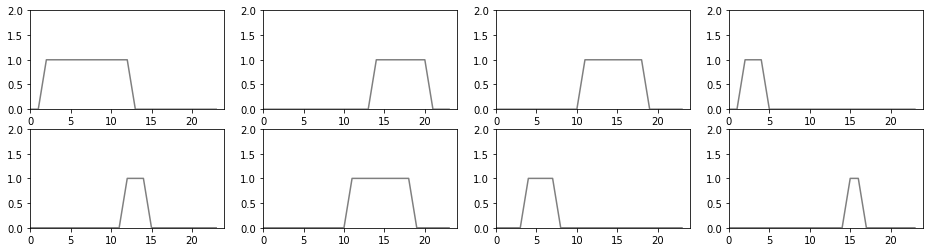

In [307]:
plt.figure(figsize = (16,4))

for i in range(8):
  plt.subplot(2,4,i+1)
  plt.plot(x.numpy()[i,:], c = 'black', alpha = 0.5)
  plt.xlim(0,length)
  plt.ylim(0,2)


## deep networks

Architecture guidelines for stable Deep Convolutional GANs (Radford et al. 2016)

- Replace any pooling layers with strided convolutions (discriminator) and fractional-strided
convolutions (generator).
- Use batchnorm in both the generator and the discriminator.
- Remove fully connected hidden layers for deeper architectures.
- Use ReLU activation in generator for all layers except for the output, which uses Tanh.
- Use LeakyReLU activation in the discriminator for all layers.



In [308]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [316]:
class CNNGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.cnn = nn.Sequential(    
            nn.ConvTranspose1d(32, 16, kernel_size = 4, stride = 2, padding = 0, bias = False),
            nn.BatchNorm1d(16),
            nn.ReLU(True),

            nn.ConvTranspose1d(16, 8, kernel_size = 4, stride = 2, padding = 0, bias = False),
            nn.BatchNorm1d(8),
            nn.ReLU(True),

            nn.ConvTranspose1d(8, 1, kernel_size = 6, stride = 2, padding = 0, bias = False),
            nn.Tanh()
         )
        

    def forward(self, z):    
      out = self.cnn(z)
      return out

In [317]:
gen = CNNGenerator()
z = torch.rand((batch_size, 32, 1)) # (batch, features, len)

out = gen(z)
out.shape

torch.Size([100, 1, 24])

In [323]:
class CNNDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

                
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 8,  kernel_size = 6, stride = 2, padding = 0, bias = False),
            nn.BatchNorm1d(8),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(8, 16,  kernel_size = 6, stride = 2, padding = 0, bias = False),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2, inplace=False),

            nn.Conv1d(16, 1, kernel_size=3, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):

        out = self.cnn(x.view((batch_size, 1, 24)))
        return out.squeeze(1)


In [324]:
dis = CNNDiscriminator()
dis(x).shape

torch.Size([100, 1])

# training

In [325]:
def weights_init(m):
    """
    This function initializes the model weights randomly from a 
    Normal distribution. This follows the specification from the DCGAN paper.
    https://arxiv.org/pdf/1511.06434.pdf
    Source: https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [345]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = CNNGenerator().to(device)
discriminator = CNNDiscriminator().to(device)


### WEIGHT INITIALIZATION
generator.apply(weights_init)
discriminator.apply(weights_init)

criterion = nn.BCELoss()

lr = 0.0002
optim_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

In [346]:
# Train the model
nb_epoch = 1000

for epoch in range(nb_epoch):
    i = 0

    # if epoch%50 == 0:
    #     lr /= 10
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, x in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)

        discriminator.zero_grad()
        pred_real = discriminator(x)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((batch_size, 32, 1), device=device)
        with torch.no_grad():
            fake_samples = generator(z)
        pred_fake = discriminator(fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()
        
        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((batch_size, 32, 1), device=device) 

        generated = generator(z)
        classifications = discriminator(generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()
    
    if epoch%100 == 0:
      print('Epoch [{}/{}] -----------------------------------------------------------------------------'
          .format(epoch+1, nb_epoch, i, len(train_loader)))
      print('G: {}, Dr : {}, Df : {}'
          .format(loss_g_running/batch, loss_d_real_running/batch, loss_d_fake_running/batch))



Epoch [1/1000] -----------------------------------------------------------------------------
G: 0.8711055815219879, Dr : 0.8397945910692215, Df : 0.8699724078178406
Epoch [101/1000] -----------------------------------------------------------------------------
G: 1.0425561964511871, Dr : 0.7588016390800476, Df : 0.7754261940717697
Epoch [201/1000] -----------------------------------------------------------------------------
G: 0.9887144267559052, Dr : 0.6092533096671104, Df : 0.8077983111143112
Epoch [301/1000] -----------------------------------------------------------------------------
G: 1.502502292394638, Dr : 0.5651492327451706, Df : 0.5255930572748184
Epoch [401/1000] -----------------------------------------------------------------------------
G: 1.2773667871952057, Dr : 0.711306057870388, Df : 0.708501435816288
Epoch [501/1000] -----------------------------------------------------------------------------
G: 1.079526275396347, Dr : 0.5827756747603416, Df : 0.7144529223442078
Epoc

## visualizing

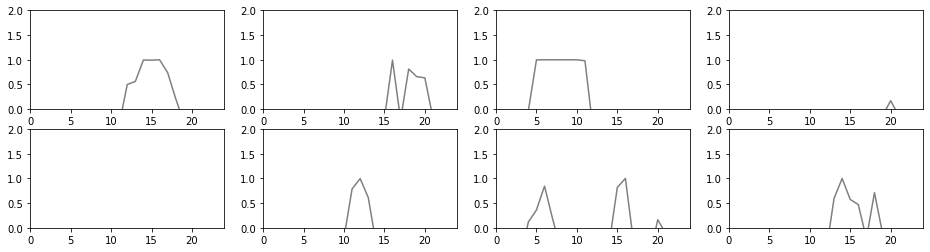

In [347]:
traj_sim = generated.detach().numpy()

plt.figure(figsize = (16,4))

for i in range(8):
  plt.subplot(2,4,i+1)
  plt.plot(traj_sim[i,0,:], c = 'black', alpha = 0.5)
  plt.xlim(0,length)
  plt.ylim(0,2)